# RCS (Relative Calibration System) Tuning Analysis

## Overview

This notebook analyzes the **tuning** of the simplified Relative Calibration System (sRCS) for the Wide Field Instrument (WFI). Tuning is a comprehensive performance characterization where we measure the actual flux delivered to the Focal Plane Array (FPA) across the full range of commanded LED settings.

### What is RCS Tuning?

**RCS Tuning** is the process of characterizing the relationship between:
- **Input**: FPGA programmable code (LED driver register setting)
- **Output**: Actual flux at the FPA [e⁻/pix/s]

This calibration is critical because:
1. Each LED has **unique light output characteristics**
2. The relationship between code and flux is **non-linear**
3. We need **accurate flux prediction** for science calibration

### LED Configuration

**Code Ranges**:
- **Low Range**: 0 - 65,535 (standard 16-bit)
- **High Range**: 65,536 - 131,070 (extended range for higher flux)

### Key Terminology

- **Code**: FPGA programmable register value that controls LED current
- **FPA**: Focal Plane Array (detector array with 18 SCAs)
- **SCA**: Sensor Chip Assembly (individual detector in the array)
- **med_flux_mean**: Average of median flux measurements across all SCAs
- **Photodiode (PD1, PD2)**: Reference detectors monitoring LED output PD1=InGaAs, PD2=MCT
- **Flux**: Light intensity at detector [e⁻/pix/s]

### Analysis Workflow

1. **Data Integration**: Combine RCS telemetry with FPA measurements by timestamp
2. **Calibration Fitting**: Polynomial and spline models relating code → flux
3. **Cross-Campaign Comparison**: Compare TVAC1, TVAC2, and SCIPA TVAC results
4. **Validation**: Assess calibration accuracy and consistency

### Test Campaigns

- **WFI TVAC1**: First thermal vacuum test (reference baseline)
- **WFI TVAC2**: Second thermal vacuum test (with instrument changes)
- **SCIPA TVAC**: Side A/B characterization at 200K

---

## 1. Data Integration: Combine RCS & FPA Measurements

### Purpose
Synchronize RCS telemetry (LED settings, photodiode readings) with FPA measurements (SCA flux values) using timestamps.

### Data Sources
- **RCS Data**: LED codes, currents, photodiode voltages from telemetry
- **FPA Data**: SCA median flux measurements from image analysis

### Key Challenge
RCS and FPA data are collected independently and must be aligned temporally to associate LED settings with detector responses.

In [ ]:
import traceback
from srcs_utils import process_wfi_dataset
import pandas as pd

side = 'B'

if side == 'A':
    fpa = pd.read_csv('data/tuning/SCIPA_SideA_Tuning_Stability.csv').dropna(subset=['Timestamp'])#.set_index('Timestamp')
else:
    fpa = pd.read_csv('data/tuning/SCIPA_SideB_Tuning_Stability.csv').dropna(subset=['Timestamp'])

if side == 'A':
    rcst = pd.read_parquet('data/tuning/25092913_SideA_tuning.parquet')
else:
    rcst = pd.read_parquet('data/tuning/25091517_Bside_200K_RCS_TUNING.parquet')
rcs = process_wfi_dataset(side, rcst).set_index('time')

fpa['band'] = 0
fpa['bank'] = 0
fpa['flux'] = 0.0
fpa['side'] = 'UNK'
fpa['pd1'] = 0.0
fpa['pd2'] = 0.0
fpa['current'] = 0.0
fpa['code'] = 0.0
fpa['ledfv'] = 0.0
fpa['ledt'] = fpa.iloc[0].Timestamp
def populate_led_time(df, rcs):
    for i in range(1, len(df)):
        try:
            tm = df.index[i]
            # Create a Time object in UTC
            if not pd.isna(tm):
                        valid_indices = rcs.index[rcs.index <= tm]
                        if len(valid_indices) > 0:
                            ind = valid_indices.max()
                            if not pd.isna(ind):
                                r = rcs.loc[ind]

                                if r['end'] > tm:
                                    #print(r[['pd1', 'flux', 'band', 'bank']])
                                    #print(len(r))
                                    df.iloc[i, df.columns.get_loc('band')] = r.band
                                    df.iloc[i, df.columns.get_loc('bank')] = r.bank
                                    df.iloc[i, df.columns.get_loc('flux')] = r.flux
                                    df.iloc[i, df.columns.get_loc('side')] = r.side
                                    df.iloc[i, df.columns.get_loc('pd1')] = r.pd1
                                    df.iloc[i, df.columns.get_loc('pd2')] = r.pd2
                                    df.iloc[i, df.columns.get_loc('ledt')] = r.name
                                    df.iloc[i, df.columns.get_loc('code')] = r.code
                                    df.iloc[i, df.columns.get_loc('ledfv')] = r.ledfv
                                    df.iloc[i, df.columns.get_loc('ledfv')] = r.current

        except Exception as e:
            #print(r)
            traceback.print_exc()
            print(f'{e} - {tm}:{df.iloc[i]["SCA03_Med"] if "SCA03_Med" in df.columns else "N/A"}')

    return df

def populate_led(df, rcs):
    r = -1  # index for rcs dataframe
    prev_bank1 = None
    prev_bank2 = None
    dark = True
    for i in range(len(df)):
        # Check if BANK1 or BANK2 changed
        curr_bank1 = df.iloc[i]['BANK1']# if 'BANK1' in df.columns else None
        curr_bank2 = df.iloc[i]['BANK2']# if 'BANK2' in df.columns else None
        dark = ((curr_bank1 == 'B1_OFF') and (curr_bank2 == 'B2_OFF'))
        if (not dark) and ((curr_bank1 != prev_bank1) or (curr_bank2 != prev_bank2)):
            r += 1

        # Copy values from rcs to df
        if not dark:
            band = int(rcs.iloc[r]['band'])
            bank = rcs.iloc[r]['bank']
            flux = rcs.iloc[r]['flux']
            if (bank == 1) and (int(curr_bank1[-1]) != band):
                print(f'mismatch in band {band} bank {bank} flux {flux}')
            if (bank == 2) and (int(curr_bank2[-1]) != band):
                print(f'mismatch in band {band} bank {bank} flux {flux}')
            #print(f'copy.. LED{bank}{band}')
            df.iloc[i, df.columns.get_loc('flux')] = flux
            df.iloc[i, df.columns.get_loc('band')] = rcs.iloc[r]['band']
            df.iloc[i, df.columns.get_loc('bank')] = rcs.iloc[r]['bank']
            df.iloc[i, df.columns.get_loc('code')] = rcs.iloc[r]['code']
            df.iloc[i, df.columns.get_loc('pd1')] = rcs.iloc[r]['pd1']
            df.iloc[i, df.columns.get_loc('pd2')] = rcs.iloc[r]['pd2']
            df.iloc[i, df.columns.get_loc('ledfv')] = rcs.iloc[r]['ledfv']
            df.iloc[i, df.columns.get_loc('current')] = rcs.iloc[r]['current']

        prev_bank1 = curr_bank1
        prev_bank2 = curr_bank2
    return df

fpa = populate_led(fpa, rcs.loc[pd.Timestamp('2025-09-15 18:11:30'):])
fpa[['band', 'bank', 'BANK1', 'BANK2', 'b1_target_flux (e/px/s)', 'b2_target_flux (e/px/s)', 'flux', 'code', 'SCA01_Med']]

,band,bank,BANK1,BANK2,b1_target_flux (e/px/s),b2_target_flux (e/px/s),flux,code,SCA01_Med
0,0,0,B1_OFF,B2_OFF,0.00,0.0,0.000000,0.0,0.001028
1,0,0,B1_OFF,B2_OFF,0.00,0.0,0.000000,0.0,-0.016612
2,1,1,LED11,B2_OFF,0.10,0.0,0.149347,570.0,0.115043
3,1,2,B1_OFF,LED21,0.00,0.1,0.149383,539.0,0.179860
4,2,1,LED12,B2_OFF,0.26,0.0,0.260611,62.0,0.333047
...,...,...,...,...,...,...,...,...,...
281,0,0,B1_OFF,B2_OFF,0.00,0.0,0.000000,0.0,0.099689
282,0,0,B1_OFF,B2_OFF,0.00,0.0,0.000000,0.0,0.129361
283,0,0,B1_OFF,B2_OFF,0.00,0.0,0.000000,0.0,0.071167
284,0,0,B1_OFF,B2_OFF,0.00,0.0,0.000000,0.0,0.093900



## 2. Calibration Model Fitting

### Purpose
Create mathematical models that predict actual FPA flux from programmed LED code values.

### Why Two Models?

**Polynomial (3rd order)**:
- **Pros**: Smooth, mathematically simple, good for interpolation
- **Cons**: May not capture local variations
- **Use case**: General flux prediction, smooth curves

**Spline (cubic, s=0)**:
- **Pros**: Exact fit through all data points, captures local variations
- **Cons**: Can oscillate between points, more complex
- **Use case**: High-precision lookup, characterization plots

### Fitting Strategy

1. **Separate fits** for each LED (band/bank combination)
2. **Split by range** (low: 0-65535, high: 65536-131070)
3. **Weighted fitting**: More weight on low flux values for better log-log precision
4. **Group duplicates**: Average measurements at same code for consistency

### Output

- **Calibration curves**: Code → Flux relationship
- **Error metrics**: MAE (Mean Absolute Error), R² score
- **Compensation factors**: Ratio of measured/predicted flux

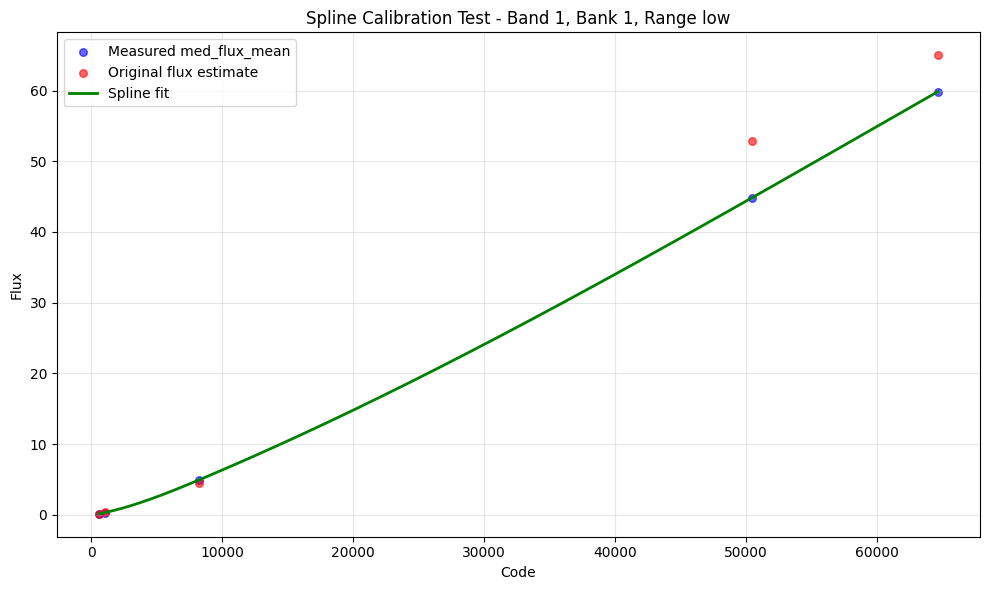

Calibration results by band/bank/range:
    band  bank range  n_samples    flux_mae  flux_relative_error_%  poly_mae  \
0      1     1   low          5    2.724171              13.389151  0.044316   
1      1     1  high          4  289.917398              11.028451  0.053191   
2      1     2   low          5    3.113345              15.358057  0.065008   
3      1     2  high          4  301.269261              10.805637  0.048378   
4      2     1   low          6    3.123551              10.955970  0.044759   
5      2     1  high          4   93.872061              13.716427  0.439163   
6      2     2   low          6    3.340105              11.531641  0.043015   
7      2     2  high          4   79.768117              11.844739  0.290598   
8      3     1   low          6    0.420395               3.052222  0.044205   
9      3     1  high          4  157.466847               4.096692  0.019184   
10     3     2   low          5    1.181607               3.465074  0.116024   


,band,bank,range,n_samples,flux_mae,flux_relative_error_%,poly_mae,poly_r2,poly_mean_comp_factor,spline_mae,spline_r2,spline_mean_comp_factor
0,1,1,low,5,2.724171,13.389151,0.044316,0.999997,0.910968,2.381428e-15,1.0,0.915730
1,1,1,high,4,289.917398,11.028451,0.053191,1.000000,0.938783,4.618528e-14,1.0,0.938782
2,1,2,low,5,3.113345,15.358057,0.065008,0.999993,0.903319,5.773160e-16,1.0,0.913924
3,1,2,high,4,301.269261,10.805637,0.048378,1.000000,0.904223,1.207923e-13,1.0,0.904223
4,2,1,low,6,3.123551,10.955970,0.044759,0.999998,1.123382,2.997602e-15,1.0,1.124375
5,2,1,high,4,93.872061,13.716427,0.439163,1.000000,1.180253,1.563194e-13,1.0,1.180234
6,2,2,low,6,3.340105,11.531641,0.043015,0.999999,1.131031,1.295260e-15,1.0,1.131481
7,2,2,high,4,79.768117,11.844739,0.290598,1.000000,1.148349,9.947598e-14,1.0,1.148365
8,3,1,low,6,0.420395,3.052222,0.044205,0.999998,0.990585,1.582068e-15,1.0,0.991980
9,3,1,high,4,157.466847,4.096692,0.019184,1.000000,0.993958,2.842171e-14,1.0,0.993958


In [2]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

calibration_results = []
poly_models = {}
spline_models = {}

for band_num in range(1, 7):
    for bank_num in range(1, 3):
        for range_type in ['low', 'high']:
            # Filter data for current band/bank and range
            mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num)
            if range_type == 'low':
                mask = mask & (fpa['code'] <= 65535)
            else:
                mask = mask & (fpa['code'] >= 65536)

            subset = fpa[mask].copy()

            if len(subset) > 0:
                # Sort by code for consistent fitting
                subset = subset.sort_values('code')

                # Remove duplicates by averaging med_flux_mean for same codes
                subset_grouped = subset.groupby('code').agg({
                    'med_flux_mean': 'mean',
                    'flux': 'mean',
                    'band': 'first',
                    'bank': 'first'
                }).reset_index()

                # Ensure strictly increasing by adding small epsilon to duplicate codes
                codes = subset_grouped['code'].values
                if len(codes) > 1:
                    for i in range(1, len(codes)):
                        if codes[i] <= codes[i-1]:
                            codes[i] = codes[i-1] + 1e-6
                    subset_grouped['code'] = codes

                # Create weights that are inversely proportional to flux values
                # This gives more weight to low flux values for better log-log precision
                flux_values = subset_grouped['med_flux_mean'].values
                # Avoid division by zero and ensure positive weights
                weights = 1.0 / (flux_values + 1e-10)
                # Normalize weights to have mean of 1
                weights = weights / weights.mean()
                # Polynomial fitting (3rd order) with weights
                poly = PolynomialFeatures(degree=3, include_bias=True)
                X_poly = poly.fit_transform(subset_grouped[['code']].values)

                # Fit weighted polynomial model: med_flux_mean = f(code)
                poly_model = LinearRegression()
                poly_model.fit(X_poly, subset_grouped['med_flux_mean'], sample_weight=weights)
                poly_pred = poly_model.predict(X_poly)
                # Calculate compensation factors from polynomial
                compensation_poly = poly_pred / subset_grouped['flux'].values
                mean_comp_factor_poly = np.mean(compensation_poly)

                # Spline fitting with s=0 for exact interpolation
                try:
                    spline = UnivariateSpline(subset_grouped['code'], subset_grouped['med_flux_mean'], k=3, s=0)
                    spline_pred = spline(subset_grouped['code'])
                except:
                    # If spline fails, use a simpler approach
                    spline = UnivariateSpline(subset_grouped['code'], subset_grouped['med_flux_mean'], k=1, s=0)
                    spline_pred = spline(subset_grouped['code'])

                # Calculate compensation factors from spline
                compensation_spline = spline_pred / subset_grouped['flux'].values
                mean_comp_factor_spline = np.mean(compensation_spline)

                # Store models
                key = (band_num, bank_num, range_type)
                poly_models[key] = (poly, poly_model)
                spline_models[key] = (spline, subset_grouped)

                # Calculate error metrics
                poly_mae = mean_absolute_error(subset_grouped['med_flux_mean'], poly_pred)
                spline_mae = mean_absolute_error(subset_grouped['med_flux_mean'], spline_pred)

                poly_r2 = r2_score(subset_grouped['med_flux_mean'], poly_pred)
                spline_r2 = r2_score(subset_grouped['med_flux_mean'], spline_pred)

                # Error in original flux estimate
                flux_mae = mean_absolute_error(subset_grouped['med_flux_mean'], subset_grouped['flux'])
                flux_relative_error = np.mean(np.abs((subset_grouped['med_flux_mean'] - subset_grouped['flux']) / subset_grouped['med_flux_mean'])) * 100

                calibration_results.append({
                    'band': band_num,
                    'bank': bank_num,
                    'range': range_type,
                    'n_samples': len(subset_grouped),
                    'flux_mae': flux_mae,
                    'flux_relative_error_%': flux_relative_error,
                    'poly_mae': poly_mae,
                    'poly_r2': poly_r2,
                    'poly_mean_comp_factor': mean_comp_factor_poly,
                    'spline_mae': spline_mae,
                    'spline_r2': spline_r2,
                    'spline_mean_comp_factor': mean_comp_factor_spline
                })

# Create results dataframe
calibration_df = pd.DataFrame(calibration_results)

# Apply polynomial calibration to create calibrated flux
fpa['flux_calibrated_poly'] = fpa['flux'].copy()
fpa['compensation_factor_poly'] = 1.0

for _, row in calibration_df.iterrows():
    if row['range'] == 'low':
        mask = (fpa['band'] == row['band']) & (fpa['bank'] == row['bank']) & (fpa['code'] <= 65535)
    else:
        mask = (fpa['band'] == row['band']) & (fpa['bank'] == row['bank']) & (fpa['code'] >= 65536)

    if mask.sum() > 0:
        key = (row['band'], row['bank'], row['range'])
        poly, poly_model = poly_models[key]

        # Get polynomial predictions for this band/bank/range
        subset_codes = fpa.loc[mask, 'code'].values.reshape(-1, 1)
        X_poly = poly.transform(subset_codes)
        poly_pred = poly_model.predict(X_poly)

        # Calculate and apply compensation factors
        comp_factors = poly_pred / fpa.loc[mask, 'flux'].values
        fpa.loc[mask, 'flux_calibrated_poly'] = fpa.loc[mask, 'flux'] * comp_factors
        fpa.loc[mask, 'compensation_factor_poly'] = comp_factors

# Apply spline calibration to create calibrated flux
fpa['flux_calibrated_spline'] = fpa['flux'].copy()
fpa['compensation_factor_spline'] = 1.0

for _, row in calibration_df.iterrows():
    if row['range'] == 'low':
        mask = (fpa['band'] == row['band']) & (fpa['bank'] == row['bank']) & (fpa['code'] <= 65535)
    else:
        mask = (fpa['band'] == row['band']) & (fpa['bank'] == row['bank']) & (fpa['code'] >= 65536)

    if mask.sum() > 0:
        key = (row['band'], row['bank'], row['range'])
        spline, _ = spline_models[key]

        # Get spline predictions for this band/bank/range
        subset_codes = fpa.loc[mask, 'code'].values
        spline_pred = spline(subset_codes)

        # Calculate and apply compensation factors
        comp_factors = spline_pred / fpa.loc[mask, 'flux'].values
        fpa.loc[mask, 'flux_calibrated_spline'] = fpa.loc[mask, 'flux'] * comp_factors
        fpa.loc[mask, 'compensation_factor_spline'] = comp_factors

# Calculate overall metrics
fpa['error_before'] = np.abs(fpa['med_flux_mean'] - fpa['flux'])
fpa['error_after_poly'] = np.abs(fpa['med_flux_mean'] - fpa['flux_calibrated_poly'])
fpa['error_after_spline'] = np.abs(fpa['med_flux_mean'] - fpa['flux_calibrated_spline'])

# Plot one of the splines against the real measured data as a test
if len(spline_models) > 0:
    test_key = list(spline_models.keys())[0]
    spline, subset_grouped = spline_models[test_key]
    band_num, bank_num, range_type = test_key

    plt.figure(figsize=(10, 6))
    code_range = np.linspace(subset_grouped['code'].min(), subset_grouped['code'].max(), 1000)
    spline_curve = spline(code_range)

    plt.scatter(subset_grouped['code'], subset_grouped['med_flux_mean'],
            label='Measured med_flux_mean', color='blue', alpha=0.6, s=30)
    plt.scatter(subset_grouped['code'], subset_grouped['flux'],
            label='Original flux estimate', color='red', alpha=0.6, s=30)
    plt.plot(code_range, spline_curve,
            label='Spline fit', color='green', linewidth=2)

    plt.xlabel('Code')
    plt.ylabel('Flux')
    plt.title(f'Spline Calibration Test - Band {band_num}, Bank {bank_num}, Range {range_type}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Calibration results by band/bank/range:")
print(calibration_df)
print(f"\nMean absolute error before calibration: {fpa['error_before'].mean():.4f}")
print(f"Mean absolute error after polynomial calibration: {fpa['error_after_poly'].mean():.4f}")
print(f"Mean absolute error after spline calibration: {fpa['error_after_spline'].mean():.4f}")

# Create polynomial equations as strings for reference
poly_equations = {}
for (band_num, bank_num, range_type), (poly, poly_model) in poly_models.items():
    coef = poly_model.coef_
    intercept = poly_model.intercept_
    equation = f"flux_calibrated = flux * ({intercept:.4f} + {coef[1]:.4f}*code + {coef[2]:.4f}*code^2 + {coef[3]:.4f}*code^3) / flux"
    poly_equations[(band_num, bank_num, range_type)] = equation

calibration_df


## 3. Generate SCIPA TVAC Calibration Plots (PowerPoint Export)

### Purpose
Create visual comparison of:
1. **Raw SCA measurements** (individual detector readings)
2. **Original flux estimate** (from RCS photodiode)
3. **Polynomial fit** (smooth calibration curve)
4. **Spline fit** (exact interpolation)
5. **Measured mean flux** (average across SCAs)

### Plot Configuration
- **Log-log scale**: Better visualization across wide flux range (0.1 to 1000+ e⁻/pix/s)
- **Two plots per slide**: Low range (left) and high range (right)
- **Color coding**:
  - Orange: Individual SCA measurements (scatter)
  - Red: Original RCS estimate
  - Green: Spline fit
  - Orange dashed: Polynomial fit
  - Blue: Measured mean (target)

### Output
PowerPoint file with one slide per LED (band/bank combination)

In [3]:
import analysis_export_utils as ex
ex.create_ppt("templates/rst_scipa.pptx")
plt.close('all')

SCAlist = [f'SCA{i:02d}' for i in range(1, 19)]
SCAlist.remove("SCA08")
meds = (np.array(SCAlist) + '_Med').tolist()

for test_key in spline_models.keys():
    spline, subset_grouped = spline_models[test_key]
    poly, poly_model = poly_models[test_key]  # Get the polynomial model components
    band_num, bank_num, range_type = test_key

    fig = plt.figure(dpi=120)
    fig.set_size_inches(6, 4.5)
    if range_type == 'low':
        code_range = np.linspace(0, 65535, 1000)
    else:
        code_range = np.linspace(65536, 65536*2, 1000)
    code_range = np.linspace(subset_grouped['code'].min(), subset_grouped['code'].max(), 1000)

    # Calculate both spline and polynomial predictions
    spline_curve = spline(code_range)
    code_range_2d = code_range.reshape(-1, 1)
    poly_features = poly.transform(code_range_2d)
    poly_curve = poly_model.predict(poly_features)

    if range_type == 'low':
        mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num) & (fpa['code'] <= 65535)
    else:
        mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num) & (fpa['code'] >= 65536)
    for i, sca in enumerate(meds):
        if i == 0:
            plt.scatter(fpa[mask]['code'], fpa.loc[mask, sca], s=20, alpha=0.3, label='SCA Measurements', color='C1')
        else:
            plt.scatter(fpa[mask]['code'], fpa.loc[mask, sca], s=20, alpha=0.3, color='C1')

    plt.scatter(subset_grouped['code'], subset_grouped['flux'],
            label='Original flux estimate', color='red', alpha=0.7, s=30)

    plt.plot(code_range, spline_curve, alpha=0.7,
            label='Spline fit', color='green', linewidth=2)

    # Add the polynomial fit curve
    plt.plot(code_range, poly_curve, alpha=0.7,
            label='Polynomial fit', color='orange', linewidth=2, linestyle='--')

    plt.scatter(subset_grouped['code'], subset_grouped['med_flux_mean'],
            label='Measured med_flux_mean', color='blue', alpha=0.8, s=30)

    plt.xlabel('Code')
    plt.ylabel('Flux')
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Calibration Comparison - Band {band_num}, Bank {bank_num}, Range {range_type}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.set_tight_layout(True)
    if range_type == 'low':
        ex.add_figure(title=f'Calibration Comparison - Band {band_num}, Bank {bank_num}', xd=6, yd=4.5, x0=0.56, y0=1.84)
    else:
        #plt.xscale('log')
        #plt.yscale('log')
        plt.tight_layout()
        ex.add_figure(newslide=False, xd=6, yd=4.5, x0=6.78, y0=1.84)
        plt.close('all')

ex.save_ppt(f'Side{side}_RCS_tuning_SCIPA_TVAC_only.pptx')

## 4. Combined Range Calibration Plots (High + Low on Same Plot)

### What This Does
Generates a PowerPoint with **one full-width plot per LED** showing both low (0-65K) and high (65K-131K) code ranges on the same axes.

### Output File
`Side{A/B}_sRCS_tuning_scipa_only_high_and_low.pptx` - 6 slides (Bands 4-6, Banks 1-2)

### What You'll See on Each Plot

| Element | Color | Description |
|---------|-------|-------------|
| SCA scatter cloud | Orange | All 17 individual SCA measurements |
| Red circles | Red | Original RCS photodiode estimate |
| Green line | Green | Cubic spline fit (exact) |
| Orange dashed | Orange | Polynomial fit (smooth) |
| Blue circles | Blue | Mean of SCAs (ground truth) |

**Axes**: Linear X (code), Log Y (flux in e⁻/pix/s)

### Key Differences from Previous Section
- ✅ **Both ranges** on one plot (better for reports)
- ✅ **Full characterization** visible at once
- ✅ **Wider format** (13.33" × 6.17")
- ⚠️ Previous section made 2 plots/slide (low left, high right)

### What to Look For
- **Smooth transitions** between low/high ranges at code ~65K
- **Spline and polynomial agreement** (should be close)
- **Blue points between green/orange lines** (good calibration)
- **SCA scatter tightness** (consistency across detector array)


In [4]:
import analysis_export_utils as ex
ex.create_ppt("templates/rst_scipa.pptx")
plt.close('all')

SCAlist = [f'SCA{i:02d}' for i in range(1, 19)]
SCAlist.remove("SCA08")
meds = (np.array(SCAlist) + '_Med').tolist()

for test_key in spline_models.keys():
    spline, subset_grouped = spline_models[test_key]
    poly, poly_model = poly_models[test_key]  # Get the polynomial model components
    band_num, bank_num, range_type = test_key


    if range_type == 'low':
        fig = plt.figure(dpi=120)
        fig.set_size_inches(13.33, 6.17)
        code_range = np.linspace(0, 65535, 1000)
    else:
        code_range = np.linspace(65536, 65536*2, 1000)
    code_range = np.linspace(subset_grouped['code'].min(), subset_grouped['code'].max(), 1000)

    # Calculate both spline and polynomial predictions
    spline_curve = spline(code_range)
    code_range_2d = code_range.reshape(-1, 1)
    poly_features = poly.transform(code_range_2d)
    poly_curve = poly_model.predict(poly_features)

    if range_type == 'low':
        mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num) & (fpa['code'] <= 65535)
    else:
        mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num) & (fpa['code'] >= 65536)
    for i, sca in enumerate(meds):
        if i == 0:
            plt.scatter(fpa[mask]['code'], fpa.loc[mask, sca], s=20, alpha=0.3, label='SCA Measurements', color='C1')
        else:
            plt.scatter(fpa[mask]['code'], fpa.loc[mask, sca], s=20, alpha=0.3, color='C1')

    plt.scatter(subset_grouped['code'], subset_grouped['flux'],
            label='Original flux estimate', color='red', alpha=0.7, s=30)

    plt.plot(code_range, spline_curve, alpha=0.7,
            label='Spline fit', color='green', linewidth=2)

    # Add the polynomial fit curve
    plt.plot(code_range, poly_curve, alpha=0.7,
            label='Polynomial fit', color='orange', linewidth=2, linestyle='--')

    plt.scatter(subset_grouped['code'], subset_grouped['med_flux_mean'],
            label='Measured med_flux_mean', color='blue', alpha=0.8, s=30)

    plt.xlabel('Code')
    plt.ylabel('Flux')
    #plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Calibration Comparison - Band {band_num}, Bank {bank_num}, Range {range_type}')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.set_tight_layout(True)
    if range_type == 'high':
        ex.add_figure(title=f'Calibration Comparison - Band {band_num}, Bank {band_num}', xd=13.33, yd=6.17, x0=0, y0=.92)

        plt.close('all')

ex.save_ppt(f'Side{side}_sRCS_tuning_scipa_only_high_and_low.pptx')

## 5. Load Historical TVAC Data for Cross-Campaign Comparison

### What This Does
Loads and processes **RCS telemetry + FPA measurements** from previous thermal vacuum tests to compare against current SCIPA results.

### Data Sources Loaded

| Variable | Campaign | Side | Notes |
|----------|----------|------|-------|
| `tv1` | WFI TVAC1 | B | Baseline reference |
| `tv1a` | WFI TVAC1 | A | Side A reference |
| `tv2r1` | WFI TVAC2 Run 1 | B | First TVAC2 attempt |
| `tv2r2` | WFI TVAC2 Run 2 | B | Repeated side B run later in TVAC2 |

**Temperature**: All at 200K (operational)

### What Gets Processed

**For each campaign**:
1. **RCS telemetry** (.mat files) → LED codes, photodiode voltages, currents
2. **FPA data** (.xlsx files) → SCA median flux measurements
3. **Dark subtraction** → Remove detector dark current
4. **Timestamp alignment** → Match RCS settings with SCA measurements
5. **Metrics** → Calculate 60to300 settling from RCS data

### Key Functions

**`get_sca(fname)`**: 
- Parses Excel file with SCA measurements
- Extracts band/bank from column headers (handles multiple formats)
- Groups by activity number
- Returns averaged measurements per LED configuration

**`get_avgs(results, setname, sca_avg)`**:
- Dark-subtracts each SCA measurement
- Matches timestamps between RCS telemetry and FPA data
- Populates LED metadata (code, band, bank, PD readings)
- Calculates mean flux across all SCAs

### Output DataFrames

Each DataFrame (`tv1`, `tv1a`, `tv2r1`, `tv2r2`) contains:
- **SCA columns**: `SCA01_Med`, `SCA02_Med`, ... (17 detectors)
- **Flux columns**: `SCA [e-/pix/s]`, `SCA [e-/pix/s] err`
- **RCS data**: `code`, `pd1`, `pd2`, `band`, `bank`, `current`
- **Metadata**: `setname`, `time`, `dark` flag

### Why Load Historical Data?

Enables comparison to answer:
- ✅ Has LED performance changed over time?
- ✅ Are SCIPA and WFI tunings consistent?
- ✅ Do different test campaigns agree at same codes?
- ✅ Has the RCS-to-FPA calibration drifted?

### Time Correction Note
```python
if 'R2 TVAC2' in setname.upper():
    ts = ts - pd.Timedelta(seconds=37)  # Clock sync correction
```
TVAC2 Run 2 had a 37-second timestamp offset that must be corrected for alignment.

### Next Steps
These dataframes are used in subsequent sections to overlay historical measurements on SCIPA calibration curves.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from tqdm import tqdm
from os.path import basename
from scipy.io import loadmat
from srcs_utils import *
folder = 'data/tuning/'
plt.close('all')
plt.rcParams.update({'figure.max_open_warning': 50})

dataset = dict()
dataset['B 200K Tuning TVAC1'] = read_itps_mat(folder + 'sRCS_telemetry_sideb_tuning_200K_279_0530_279_1430.mat')
dataset['B 200K Tuning R1 TVAC2'] = read_itps_mat(folder + '24-097_sideB_tuning_r1_full_sRCS_telemetry.mat')
dataset['A 200K Tuning TVAC1'] = read_itps_mat(folder + 'sRCS_telemetry_sidea_tuning_200K_286.mat')
dataset['A 200K Tuning TCR42 TVAC1'] = read_itps_mat(folder + 'sRCS_telemetry_TCR42_full_291-0900_291-1500.mat')
dataset['B 200K Tuning R2 TVAC2'] = read_itps_mat(folder + '24-124_sideB_tuningR2_sRCS_telemetry.mat')

results = dict()

for setname, data in dataset.items():
    print(setname)
    results[setname] = process_wfi_dataset(setname[0], data, legacy=True).set_index('time')

table = pd.DataFrame()
for k,r in results.items():
    r['setname'] = k
    r['side'] = k[0]
    table = pd.concat((table, r))
table.iloc[0:3]


def get_sca(fname):
    sca = pd.read_excel(fname).replace(np.nan, 0)
    if 'A' in sca.columns:
        sca['activity'] = sca['A']
    else:
        sca['activity'] = sca['exp_path_done'].str.extract('/A(\d+)_').astype(int)
    if 'exp_path_done' in sca.columns:
        sca['exp'] = sca['exp_path_done'].str.extract('_exp(\d+)')

    sca['dark'] = sca['WFI_OTP_TARGETTYPE'].str.contains('DARK')
    # TODO: this is an issue, there is another sytnax... BANK1, BANK2 that looks like LED syntax..

    if 'LED' in sca.columns:
        sca['band'] = sca['LED'].str[-1].astype(int)
        sca['bank'] = sca['LED'].str[-2].astype(int)
    elif 'BANK1' in sca.columns:
        sca['BANK1'] = sca['BANK1'].replace('B1_OFF', '00')
        sca['BANK2'] = sca['BANK2'].replace('B2_OFF', '00')
        sca['BANK1'] = sca['BANK1'].str[-1].astype(int)
        sca['BANK2'] = sca['BANK2'].str[-1].astype(int)
        sca['band'] = sca['BANK1'] + sca['BANK2']
        sca['bank'] = 0
        for i in range(len(sca)):
            ind = sca.index[i]
            if sca.at[ind, 'BANK1'] > 0:
                sca.at[ind, 'bank'] = 1
            elif sca.at[ind, 'BANK2'] > 0:
                sca.at[ind, 'bank'] = 2

    elif 'BANK1 BAND' in sca.columns:
        sca['band'] = sca['BANK1 BAND'] + sca['BANK2 BAND']
        sca['bank'] = 0
        for i in range(len(sca)):
            ind = sca.index[i]
            if sca.at[ind, 'BANK1 BAND'] > 0:
                sca.at[ind, 'bank'] = 1
            elif sca.at[ind, 'BANK2 BAND'] > 0:
                sca.at[ind, 'bank'] = 2

    #sca['time'] = pd.to_datetime(sca['GMT'], format='%y-%j-%H:%M:%S.%f')
    sca_avg = sca.groupby('activity').mean(numeric_only=True)
    sca_avg.index = sca_avg.index.astype(int)
    if 'GMT' in sca.columns:
        sca['GMT'] = pd.to_datetime(sca['GMT'], format='%y-%j-%H:%M:%S.%f')
    else:
        # 2024-04-30T18:51:19.8
        sca['GMT'] = pd.to_datetime(sca['Timestamp'], format='%Y-%m-%dT%H:%M:%S.%f')
    sca_avg['time'] = [sca['GMT'].values[0]] + sca[sca['activity'].diff() >= 1]['GMT'].tolist()
    sca_avg.sort_index(inplace=True)

    return sca_avg

def get_avgs(results, setname, sca_avg):
    dark = 0

    r = results[setname]#.set_index('time')
    sca_cols = [[f'SCA{j:02d} [e-/pix/s]'] for j in range(1, 19)]
    sca_avg['setname'] = setname
    sca_avg['side'] = setname[0]
    sca_avg[sca_cols] = 0
    sca_avg['SCA [e-/pix/s]'] = 0.0
    sca_avg['SCA [e-/pix/s] err'] = 0.0
    sca_avg['pd1'] = np.nan
    sca_avg['pd2'] = np.nan
    sca_avg['band'] = 0
    sca_avg['bank'] = 0
    sca_avg['code'] = 0
    sca_avg['current'] = 0.0
    sca_avg['ledfv'] = 0.0
    sca_avg['ctrlv'] = 0.0
    sca_avg['60to360'] = np.nan
    sca_avg['60to300'] = np.nan
    sca_avg['ri'] = np.nan

    for i in range(len(sca_avg)):
        #print(i)
        s = sca_avg.iloc[i]
        ind = sca_avg.index[i]
        if s['dark']:
            dark = np.array([s[f'SCA{j:02d}_Med'] for j in range(1, 19)])
        else:
            med = list()
            for j in range(1, 19):
                cv = s[f'SCA{j:02d}_Med']  - dark[j-1]
                sca_avg.at[ind, f'SCA{j:02d} [e-/pix/s]'] = float(cv)
                med.append(cv)
                sca_avg.at[ind, 'SCA [e-/pix/s]'] = np.array(med).mean()
                sca_avg.at[ind, 'SCA [e-/pix/s] err'] = np.array(med).std()
            ts = sca_avg.at[ind, 'time']

            if 'R2 TVAC2' in setname.upper():
                ts = ts - pd.Timedelta(seconds=37)

            idx0 = r.index.get_indexer([ts], method='ffill')[0]
            ts = r.index[idx0]

            if len(r.loc[ts]) > 0:
                rv = r.loc[ts]
                code = rv['code']
                ctrlv = rv['ctrlv']
                ledfv = rv['ledfv']
                sca_avg.at[ind, 'code'] = code

                sca_avg.at[ind, 'current'] = rv['current']
                sca_avg.at[ind, 'pd1'] = rv['pd1']
                sca_avg.at[ind, 'pd2'] = rv['pd2']
                bank = rv['bank']
                band = rv['band']
                if (code > 96) & (band == 6):
                    xxxx = 1+1
                sca_avg.at[ind, 'band'] = band
                sca_avg.at[ind, 'bank'] = bank
                # SideB|Bank1|q=0.008271
                # SideB|Bank2|q=0.007841
                q = 0.008271 if bank == 1 else 0.007841
                sca_avg.at[ind, 'ctrlv'] = ctrlv
                sca_avg.at[ind, 'ledfv'] = ledfv
                sca_avg.at[ind, 'ri'] = idx0
                if code <= 65535:
                    #current = (ctrlv - ledfv*q)/(10000*(1 - q))
                    current = ctrlv/10000
                else:
                    current = rv['current']
                sca_avg.at[ind, 'mcurrent'] = current
                sca_avg.at[ind, 'current [mA]'] = rv['current']*1e3
                sca_avg.at[ind, 'mcurrent [mA]'] = current*1e3
                sca_avg.at[ind, '60to360'] = rv['60to360']
                sca_avg.at[ind, '60to300'] = rv['60to300']
                #sca_avg.at[ind, 'PD1 data'] = rv['PD1 data']
                #sca_avg.at[ind, 'PD2 data'] = rv['PD2 data']

    return sca_avg

# all can be uncommented. this is just for debugging
tv2_r1sca = get_sca(folder + 'OTP00618_TuningSideBNoEWA_TV2a_R1_stability.xlsx')
tv2_r2sca = get_sca(folder + 'OTP00618_TuningSideB_TV2a_run2.xlsx')
tv1_sca = get_sca(folder + 'OTP00618_TuningSideB_TV1a_stability.xlsx')
tv1a_sca = get_sca(folder + '240104_nom_sideA_tuning.xlsx')
#tv2a_sca = get_sca(folder + 'OTP00618_TuningSideA_TV2a_R1_.xlsx')

tv1a = get_avgs(results, 'A 200K Tuning TVAC1', tv1a_sca)
tv2r1 = get_avgs(results, 'B 200K Tuning R1 TVAC2', tv2_r1sca)
tv2r2 = get_avgs(results, 'B 200K Tuning R2 TVAC2', tv2_r2sca)
tv1 = get_avgs(results, 'B 200K Tuning TVAC1', tv1_sca)

<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_38995/1758110588.py:39: SyntaxWarning: invalid escape sequence '\d'
  sca['activity'] = sca['exp_path_done'].str.extract('/A(\d+)_').astype(int)
/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_38995/1758110588.py:41: SyntaxWarning: invalid escape sequence '\d'
  sca['exp'] = sca['exp_path_done'].str.extract('_exp(\d+)')


B 200K Tuning TVAC1


/Users/mrizzo/Library/CloudStorage/Box-Box/WFI/Data_Analysis/sRCS/srcs_utils.py:437: RuntimeWarning: invalid value encountered in scalar subtract
  percent.iloc[idx[1]] - percent.iloc[idx[0]]).round(4)


B 200K Tuning R1 TVAC2
A 200K Tuning TVAC1


/Users/mrizzo/miniforge3/lib/python3.12/site-packages/astropy/stats/sigma_clipping.py:1061: RuntimeWarning: Mean of empty slice
  return nanmean(self.data, axis=self.axis)
/Users/mrizzo/miniforge3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/mrizzo/miniforge3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


A 200K Tuning TCR42 TVAC1
B 200K Tuning R2 TVAC2


/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_38995/1758110588.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.01409272961023275' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sca_avg.at[ind, f'SCA{j:02d} [e-/pix/s]'] = float(cv)
/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_38995/1758110588.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.01257495419101955' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sca_avg.at[ind, f'SCA{j:02d} [e-/pix/s]'] = float(cv)
/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_38995/1758110588.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001971500074149698' has dtype i

## 6. Cross-Campaign Comparison with Historical Data

### What This Does
Overlays **historical TVAC measurements** on SCIPA calibration curves to assess consistency across test campaigns and identify any LED performance changes over time.

### Output File
`Side{A/B}_sRCS_compare_tv1_tv2_scipa.pptx`

### Plot Layout (Side-by-Side)
| Left Plot (Low Range) | Right Plot (High Range) |
|----------------------|-------------------------|
| 6" × 4.5" | 6" × 4.5" |
| Code: 0 - 65K | Code: 65K - 131K |

### What You'll See

**Plot Elements**:
| Element | Color | Description |
|---------|-------|-------------|
| Green line | Green | SCIPA spline fit |
| Orange dashed | Orange | SCIPA polynomial fit |
| Blue circles | Blue | SCIPA TVAC measurements |
| C6 circles | Purple | WFI TVAC1 (baseline) |
| C4 circles | Teal | WFI TVAC2 Run 1 |
| C5 circles | Pink | WFI TVAC2 Run 2 |
| Red circles | Red | Original RCS estimate |

**Axes**: Log-log (both X and Y)

### Quantitative Comparison Box
On each high-range plot, a **text box** shows measurements at a specific code point (2nd data point, `ind=1`):

```
Flux at programmed code XXXXX current calibration predicts XX.X e-/pix/s
WFI TVAC1:      XX.X e-/pix/s pd1: X.XXXe-XX V pd2: X.XXXe-XX V ratio: X.XXXe-XX
WFI TVAC2 R1:   XX.X e-/pix/s pd1: X.XXXe-XX V pd2: X.XXXe-XX V ratio: X.XXXe-XX
WFI TVAC2 R2:   XX.X e-/pix/s pd1: X.XXXe-XX V pd2: X.XXXe-XX V ratio: X.XXXe-XX
SCIPA TVAC:     XX.X e-/pix/s pd1: X.XXXe-XX V pd2: X.XXXe-XX V ratio: X.XXXe-XX
```

### Data Collection
Creates `measurement_list` with structured data for each LED/campaign:
- **band, bank, range**: LED identifier
- **code**: Programmed value
- **cal_flux**: Predicted from current calibration
- **flux**: Measured FPA flux
- **pd1, pd2**: Photodiode voltages
- **ratio**: Flux/PD2 (sensitivity metric)

This list feeds into the **bar chart section** that follows.


In [6]:
import analysis_export_utils as ex
ex.create_ppt("templates/rst_scipa.pptx")
plt.close('all')
measurement_list = []
SCAlist = [f'SCA{i:02d}' for i in range(1, 19)]
SCAlist.remove("SCA08")
meds = (np.array(SCAlist) + '_Med').tolist()

def mask_range(fpa, range_type):
    if range_type == 'low':
        mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num) & (fpa['code'] <= 65535)
    else:
        mask = (fpa['band'] == band_num) & (fpa['bank'] == bank_num) & (fpa['code'] >= 65536)
    return mask

for test_key in spline_models.keys():
    spline, subset_grouped = spline_models[test_key]
    poly, poly_model = poly_models[test_key]  # Get the polynomial model components
    band_num, bank_num, range_type = test_key

    fig = plt.figure(dpi=120)
    fig.set_size_inches(6, 4.5)

    code_range = np.linspace(subset_grouped['code'].min(), subset_grouped['code'].max(), 1000)

    # Calculate both spline and polynomial predictions
    spline_curve = spline(code_range)
    code_range_2d = code_range.reshape(-1, 1)
    poly_features = poly.transform(code_range_2d)
    poly_curve = poly_model.predict(poly_features)

    mask = mask_range(fpa, range_type)
    masktv2r1 = mask_range(tv2r1, range_type)
    masktv2r2 = mask_range(tv2r2, range_type)
    masktv1 = mask_range(tv1, range_type)
    masktv1a = mask_range(tv1a, range_type)

    '''
    for i, sca in enumerate(meds):
        if i == 0:
            plt.scatter(fpa[mask]['code'], fpa.loc[mask, sca], s=20, alpha=0.3, label='SCA Measurements', color='C1')
        else:
            plt.scatter(fpa[mask]['code'], fpa.loc[mask, sca], s=20, alpha=0.3, color='C1')
    '''
    plt.plot(code_range, spline_curve, alpha=0.7,
            label='Spline fit', color='green', linewidth=2)

    # Add the polynomial fit curve
    plt.plot(code_range, poly_curve, alpha=0.7,
            label='Polynomial fit', color='orange', linewidth=2, linestyle='--')

    plt.scatter(subset_grouped['code'], subset_grouped['med_flux_mean'],
            label='SCIPA TVAC', color='blue', alpha=0.8, s=30)

    if side == 'B':
        plt.scatter(tv1[masktv1]['code'].values, tv1[masktv1][meds].mean(axis=1).values, alpha=0.7,
                s=30, label='WFI TVAC1', color='C6')

        plt.scatter(tv2r1[masktv2r1]['code'].values, tv2r1[masktv2r1][meds].mean(axis=1).values, alpha=0.7,
                s=30, label='WFI TVAC2 run1', color='C4')

        plt.scatter(tv2r2[masktv2r2]['code'].values, tv2r2[masktv2r2][meds].mean(axis=1).values, alpha=0.7,
                s=30, label='WFI TVAC2 run2', color='C5')
    else:
        plt.scatter(tv1a[masktv1a]['code'].values, tv1a[masktv1a][meds].mean(axis=1).values, alpha=0.7,
                s=30, label='WFI TVAC1', color='C6')

    plt.scatter(subset_grouped['code'], subset_grouped['flux'],
            label='Original flux estimate', color='red', alpha=0.7, s=30)

    plt.xlabel('Programmed Code [DN]')
    plt.ylabel('Flux [e-/pix/s]')
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Calibration Comparison - Band {band_num}, Bank {bank_num}, Range {range_type}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.set_tight_layout(True)
    if range_type == 'low':
        ex.add_figure(title=f'Calibration Comparison - Band {band_num}, Bank {bank_num}', xd=6, yd=4.5, x0=0.56, y0=1.84)

    else:
        ind = 1
        # Get flux values at second to last code/value pair
        tv1_subset = tv1[masktv1].sort_values('code')
        tv1_code = tv1_subset.iloc[ind]['code']
        tv1_flux = tv1_subset.iloc[ind][meds].mean()
        tv1_pd1 = tv1_subset.iloc[ind]['pd1'].mean()
        tv1_pd2 = tv1_subset.iloc[ind]['pd2'].mean()

        tv2r1_subset = tv2r1[masktv2r1].sort_values('code')
        tv2r1_code = tv2r1_subset.iloc[ind]['code']
        tv2r1_flux = tv2r1_subset.iloc[ind][meds].mean()
        tv2r1_pd1 = tv2r1_subset.iloc[ind]['pd1'].mean()
        tv2r1_pd2 = tv2r1_subset.iloc[ind]['pd2'].mean()

        tv2r2_subset = tv2r2[masktv2r2].sort_values('code')
        tv2r2_code = tv2r2_subset.iloc[ind]['code']
        tv2r2_flux = tv2r2_subset.iloc[ind][meds].mean()
        tv2r2_pd1 = tv2r2_subset.iloc[ind]['pd1'].mean()
        tv2r2_pd2 = tv2r2_subset.iloc[ind]['pd2'].mean()

        fpa_subset = fpa[mask].groupby('code')[meds].mean()
        fpa_code = fpa_subset.index[ind]
        fpa_flux = fpa_subset.iloc[ind].mean()
        scipa_pd1 = fpa[mask].groupby('code')['pd1'].mean().iloc[ind]
        scipa_pd2 = fpa[mask].groupby('code')['pd2'].mean().iloc[ind]


        # Check if codes are within tolerance of 5
        codes = [tv1_code, tv2r1_code, tv2r2_code, fpa_code]
        codes_valid = (max(codes) - min(codes)) <= 5
        cal = code_to_flux('B', band_num, bank_num, fpa_code)
        # Create dictionary with measurement data
        # Create separate entries for each test
        base_data = {
            'band': band_num,
            'bank': bank_num,
            'range': range_type,
            'code': int(fpa_code),
            'cal_flux': cal
        }

        # WFI TVAC1
        tv1_data = base_data.copy()
        tv1_data.update({
            'test': 'WFI TVAC1',
            'flux': tv1_flux,
            'pd1': tv1_pd1,
            'pd2': tv1_pd2,
            'ratio': tv1_flux/tv1_pd2
        })

        # WFI TVAC2 R1
        tv2r1_data = base_data.copy()
        tv2r1_data.update({
            'test': 'WFI TVAC2 R1',
            'flux': tv2r1_flux,
            'pd1': tv2r1_pd1,
            'pd2': tv2r1_pd2,
            'ratio': tv2r1_flux/tv2r1_pd2
        })

        # WFI TVAC2 R2
        tv2r2_data = base_data.copy()
        tv2r2_data.update({
            'test': 'WFI TVAC2 R2',
            'flux': tv2r2_flux,
            'pd1': tv2r2_pd1,
            'pd2': tv2r2_pd2,
            'ratio': tv2r2_flux/tv2r2_pd2
        })

        # SCIPA TVAC
        scipa_data = base_data.copy()
        scipa_data.update({
            'test': 'SCIPA TVAC',
            'flux': fpa_flux,
            'pd1': scipa_pd1,
            'pd2': scipa_pd2,
            'ratio': fpa_flux/scipa_pd2
        })

        measurement_data = [tv1_data, tv2r1_data, tv2r2_data, scipa_data]
        for m in measurement_data:
            measurement_list.append(m)
        if side == 'B':
            text = f"Flux at programmed code {int(fpa_code)} current calibration predicts {cal:.1f} e-/pix/s\n"
            text += f"WFI TVAC1:      {tv1_flux:.1f} e-/pix/s pd1: {tv1_pd1:.3e} V pd2: {tv1_pd2:.3e} V ratio: {tv1_flux/tv1_pd1:.3e}\n"
            text += f"WFI TVAC2 R1: {tv2r1_flux:.1f} e-/pix/s pd1: {tv2r1_pd1:.3e} V pd2: {tv2r1_pd2:.3e} V ratio: {tv2r1_flux/tv2r1_pd1:.3e}\n"
            text += f"WFI TVAC2 R2: {tv2r2_flux:.1f} e-/pix/s pd1: {tv2r2_pd1:.3e} V pd2: {tv2r1_pd2:.3e} V ratio: {tv2r2_flux/tv2r2_pd1:.3e}\n"
            text += f"SCIPA TVAC:     {fpa_flux:.1f} e-/pix/s pd1: {scipa_pd1:.3e} V pd2: {scipa_pd2:.3e} V ratio: {fpa_flux/scipa_pd1:.3e}"
            #text += f"\nAll codes within 5 DN range: {'Yes' if codes_valid else 'No'}"
            ex.add_textbox(text=text, x0=0.92, y0=6.14, xd=12.08, yd=0.67, newslide=False, font_size=12)
        plt.tight_layout()
        ex.add_figure(newslide=False, xd=6, yd=4.5, x0=6.78, y0=1.84)
        plt.close('all')

ex.save_ppt(f'Side{side}_sRCS_compare_tv1_tv2_scipa.pptx')

## 7. Campaign Comparison Bar Charts

### What This Does
Generates **interactive Plotly bar charts** comparing LED performance metrics across all test campaigns (TVAC1, TVAC2 R1/R2, SCIPA).

### Output
**8 PNG files** automatically saved with descriptive names:
- `Mean_(SCA_Medians)_e-pix_s_for_Bank_1_LEDs.png` (and Bank 2)
- `Mean_(SCA_Medians)_e-pix_s_for_Bank_1_LEDs_Normalized_to_WFI_TVAC1.png` (and Bank 2)
- `Mean_(SCA_Medians)_e-pix_s_MCT_PD2_V_for_Bank_1_LEDs_Normalized_to_WFI_TVAC1.png` (and Bank 2)
- `Discrepancy_at_~50_e-pix_s_for_Bank_1_LEDs.png` (and Bank 2)

### Chart Types & Metrics

| Chart | Parameter | Shows | Normalization |
|-------|-----------|-------|---------------|
| 1-2 | Measured Flux | Absolute flux at ~50 e⁻/pix/s | None (e⁻/pix/s) |
| 3-4 | Measured Flux | Relative change vs TVAC1 | % of TVAC1 baseline |
| 5-6 | Flux/PD2 Ratio | LED sensitivity consistency | % of TVAC1 baseline |
| 7-8 | Discrepancy | Error from current calibration | e⁻/pix/s |

### Chart Features

**Layout**:
- **X-axis**: LED Bands
- **Y-axis**: Metric value
- **Bars**: Grouped by test campaign (4 bars per band)
- **Labels**: Values displayed on each bar
- **Theme**: Dark mode (Plotly dark template)

**Normalization** (when enabled):
```python
normalized_value = (test_value / TVAC1_value) × 100%
```
Shows each campaign as percentage of WFI TVAC1 baseline.

### Key Metrics Explained

**Mean (SCA Medians) e⁻/pix/s**:
- Average flux across 17 SCAs at a specific code (~50 e⁻/pix/s nominal)
- **Use**: Compare absolute performance across campaigns

**Flux/PD2 Ratio**:
- Measured flux divided by photodiode 2 voltage
- **Use**: Assess LED-to-photodiode coupling stability
- **Ideal**: Ratio stays constant across campaigns

**Discrepancy @ ~50 e⁻/pix/s**:
- `measured_flux - calibration_predicted_flux`
- **Use**: Validate calibration accuracy and changes over different campaigns

In [7]:
import plotly.graph_objects as go
summary = pd.DataFrame(measurement_list)

def create_parameter_chart(summary, parameter='flux', bank=1, normalize=False):
    fig = go.Figure()

    # Get unique bands and tests
    bands = summary['band'].unique()
    tests = summary['test'].unique()

    # Create a trace for each test
    for test in tests:
        test_data = summary[(summary['test'] == test) & (summary['bank'] == bank)].copy()

        if normalize:
            # For each band, normalize to the first test's value
            for band in bands:
                band_mask = test_data['band'] == band
                if band_mask.any():
                    # Get reference value (first test for this band)
                    ref_data = summary[(summary['bank'] == bank) & (summary['band'] == band) & (summary['test'] == tests[0])]
                    if not ref_data.empty:
                        ref_value = ref_data[parameter].iloc[0]
                        if ref_value != 0:
                            test_data.loc[band_mask, parameter] = (test_data.loc[band_mask, parameter] / ref_value) * 100

        display_values = test_data[parameter]
        text_values = [f'{v:.1f}{"%" if normalize else ""}' for v in display_values]

        fig.add_trace(go.Bar(
            x=test_data['band'],
            y=display_values,
            name=f'{test}',
            text=text_values,
            textposition='auto'
        ))

    # Update layout
    title_suffix = ' (Normalized to WFI TVAC1)' if normalize else ''
    y_label = f'{parameter} (%)' if normalize else parameter
    title = f'{parameter} for Bank {bank} LEDs {title_suffix}'

    fig.update_layout(
        title=title,
        xaxis_title='Band',
        yaxis_title=y_label,
        barmode='group',
        template='plotly_dark',
        xaxis={'categoryorder': 'array', 'categoryarray': sorted(bands)},
        legend_title='Test',
        width=600,
        height=450
    )

    fig.show()

    # Save as PNG using title as filename
    filename = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('@', 'at') + '.png'
    fig.write_image(filename, width=850, height=450, scale=2)
    return fig

summary['Discrepancy @ ~50 e-/pix/s'] = summary['flux'] - summary['cal_flux']
summary['Mean (SCA Medians) e-/pix/s / MCT PD2 [V]'] = summary['ratio']
summary['Mean (SCA Medians) e-/pix/s'] = summary['flux']
create_parameter_chart(summary, 'Mean (SCA Medians) e-/pix/s', 1)
create_parameter_chart(summary, 'Mean (SCA Medians) e-/pix/s', 2)
create_parameter_chart(summary, 'Mean (SCA Medians) e-/pix/s', 1, normalize=True)
create_parameter_chart(summary, 'Mean (SCA Medians) e-/pix/s', 2, normalize=True)
create_parameter_chart(summary, 'Mean (SCA Medians) e-/pix/s / MCT PD2 [V]', 1, normalize=True)
create_parameter_chart(summary, 'Mean (SCA Medians) e-/pix/s / MCT PD2 [V]', 2, normalize=True)
create_parameter_chart(summary, 'Discrepancy @ ~50 e-/pix/s', 1, normalize=False);
create_parameter_chart(summary, 'Discrepancy @ ~50 e-/pix/s', 2, normalize=False);


# Publication Quality Chart

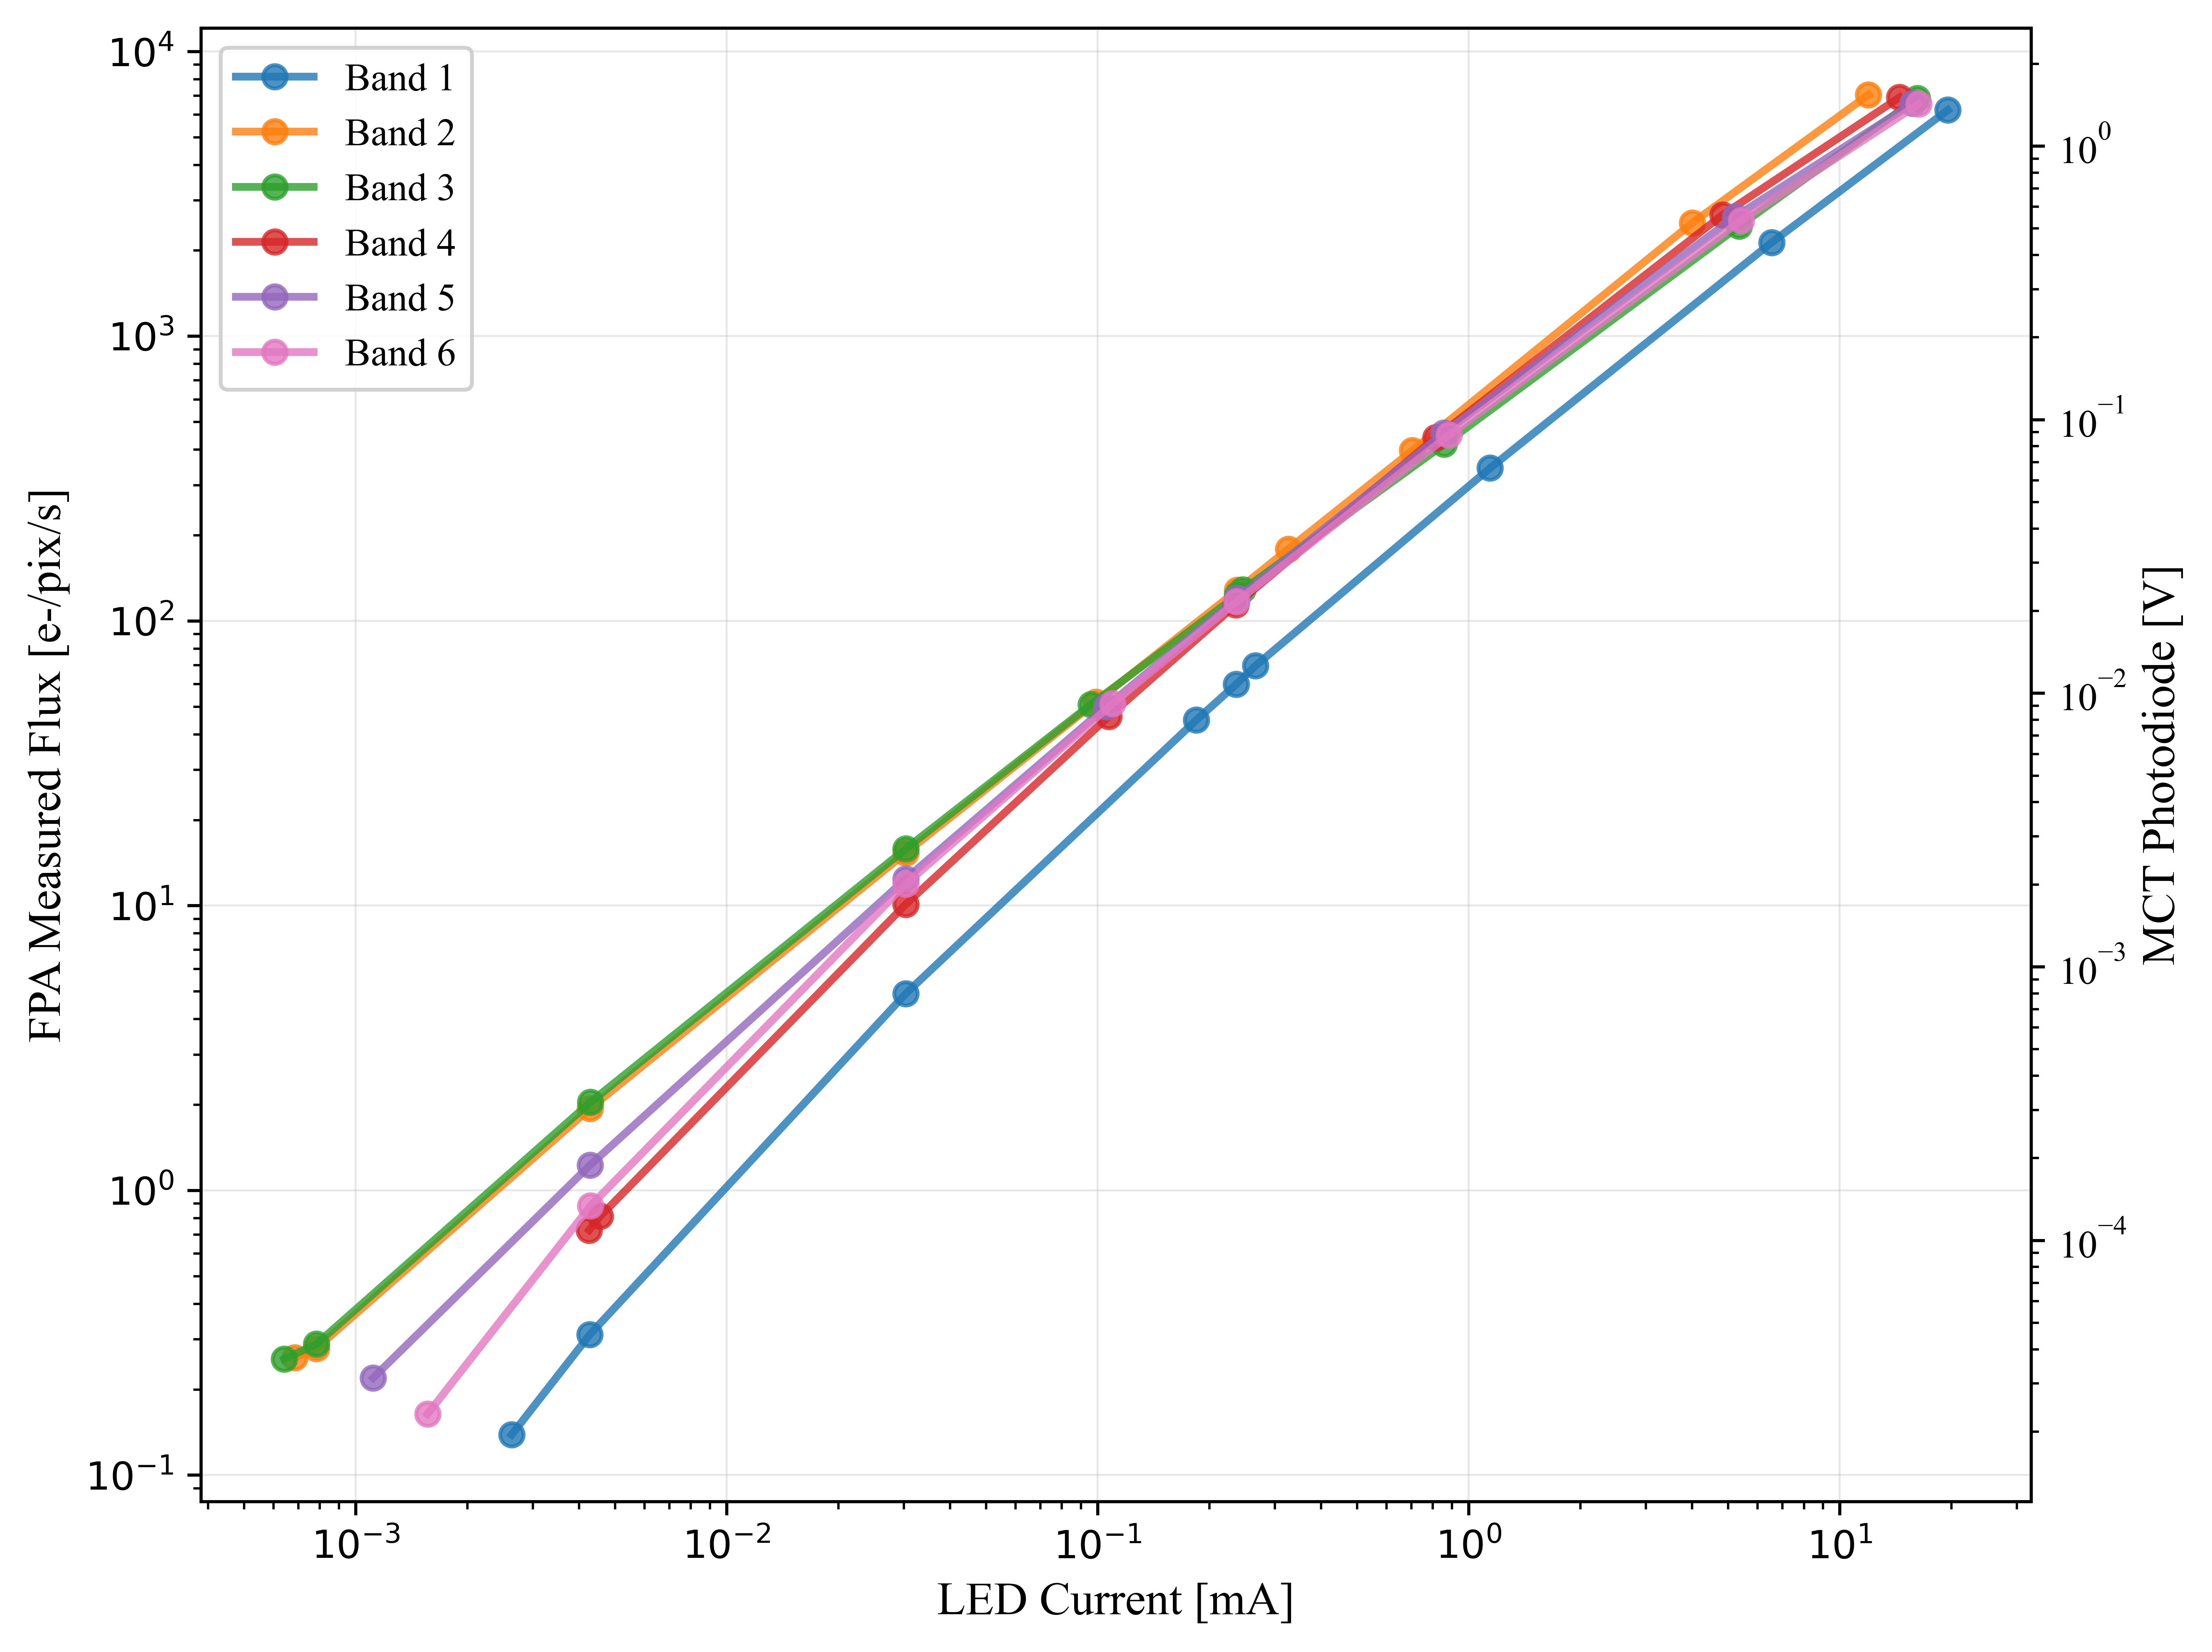

In [8]:
import matplotlib.pyplot as plt
import numpy as np
plt.close('all')
max_code = 2*65536

SCAlist = [f'SCA{i:02d}' for i in range(1, 19)]
SCAlist.remove("SCA08")
meds = (np.array(SCAlist) + '_Med').tolist()
fig, ax1 = plt.figure(dpi=800), plt.gca()
fig.set_size_inches(8, 6)

colors = plt.cm.tab10(np.linspace(0, 0.6, 6))

plt.rcParams['font.family'] = 'Times New Roman'

ax2 = ax1.twinx()
for band in range(1, 7):
    subset_grouped = fpa[(fpa.band == band) & (fpa.bank == 1) & (fpa.code < max_code) & (fpa.current > 0)]

    subset_low_current = subset_grouped[['code', 'current', 'pd1', 'pd2', 'med_flux_mean']].groupby('code').mean()
    ax1.plot(subset_low_current['current']*1000, subset_low_current['med_flux_mean'],
            '-o', color=colors[band-1], label=f'Band {band}',
            linewidth=2, markersize=6, alpha=0.8)

    ax2.plot(subset_low_current['current']*1000, subset_low_current['pd2'],
            '--s', color=colors[band-1],
            linewidth=1.5, markersize=4, alpha=0.0)

ax1.set_xlabel('LED Current [mA]', fontsize=12, fontname='Times New Roman')
ax1.set_ylabel('FPA Measured Flux [e-/pix/s]', fontsize=12, color='black', fontname='Times New Roman')
ax2.set_ylabel('MCT Photodiode [V]', fontsize=12, color='black', fontname='Times New Roman')

ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.legend(loc='upper left', fontsize=10, framealpha=0.9, prop={'family': 'Times New Roman'})

ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xscale('log')
plt.tight_layout()
plt.savefig('plots/SCIPA Side B Low Current Range LED Measurements2')